In [1]:
import os
print(os.listdir())

['marketing_campaign.csv', '.ipynb_checkpoints', 'Untitled.ipynb']


In [2]:
import pandas as pd

df = pd.read_csv("marketing_campaign.csv", sep=';')

print(df.head())
print(df.columns.tolist())
print(df.shape)

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  2012-09-04       58       635  ...                  7             0   
1  2014-03-08       38        11  ...                  5             0   
2  2013-08-21       26       426  ...                  4             0   
3  2014-02-10       26        11  ...                  6             0   
4  2014-01-19       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
print(df.isnull().sum())

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


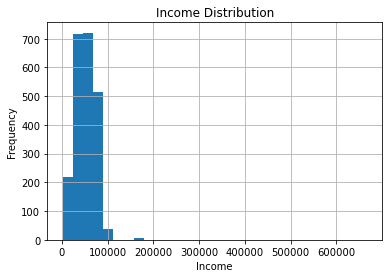

In [5]:
import matplotlib.pyplot as plt

df["Income"].hist(bins=30)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.show()

Education
2n Cycle      47633.190000
Basic         20306.259259
Graduation    52720.373656
Master        52917.534247
PhD           56145.313929
Name: Income, dtype: float64


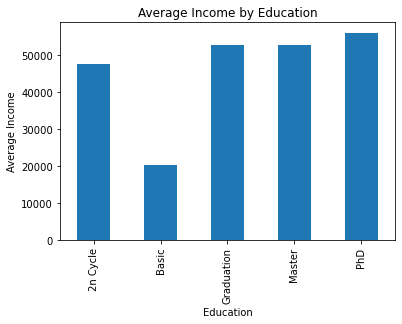

In [6]:
education_income = df.groupby("Education")["Income"].mean()

print(education_income)

education_income.plot(kind="bar")

plt.title("Average Income by Education")
plt.xlabel("Education")
plt.ylabel("Average Income")

plt.show()

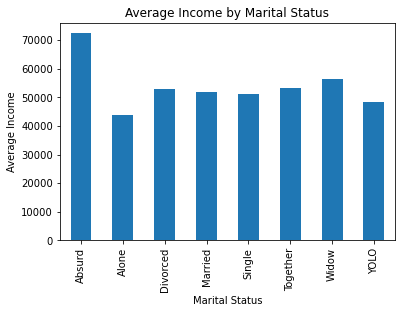

In [7]:
marital_income = df.groupby("Marital_Status")["Income"].mean()

marital_income.plot(kind="bar")

plt.title("Average Income by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Average Income")

plt.show()

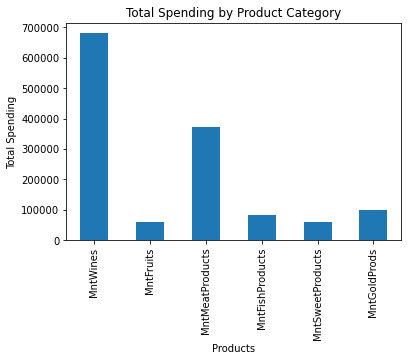

In [8]:
products = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df[products].sum().plot(kind="bar")

plt.title("Total Spending by Product Category")
plt.xlabel("Products")
plt.ylabel("Total Spending")

plt.show()

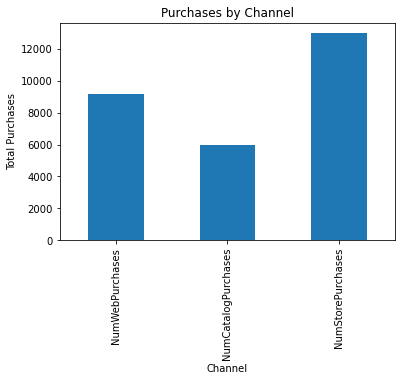

In [9]:
channels = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

df[channels].sum().plot(kind="bar")

plt.title("Purchases by Channel")
plt.xlabel("Channel")
plt.ylabel("Total Purchases")

plt.show()

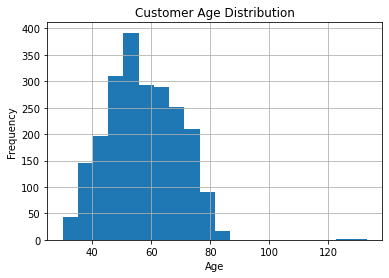

In [10]:
df["Age"] = 2026 - df["Year_Birth"]

df["Age"].hist(bins=20)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

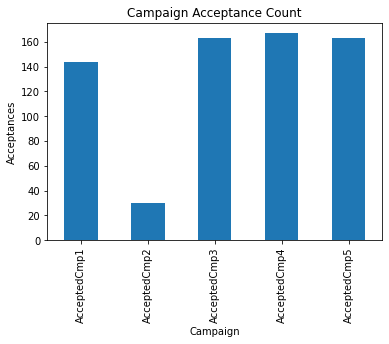

In [11]:
campaigns = ["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5"]

df[campaigns].sum().plot(kind="bar")
plt.title("Campaign Acceptance Count")
plt.xlabel("Campaign")
plt.ylabel("Acceptances")
plt.show()

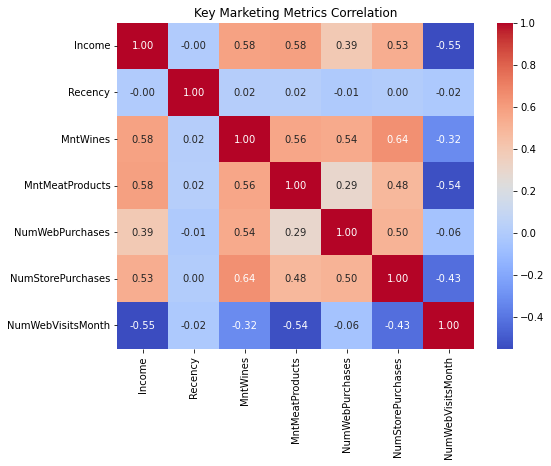

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

selected_columns = [
    "Income",
    "Recency",
    "MntWines",
    "MntMeatProducts",
    "NumWebPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

corr = df[selected_columns].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Key Marketing Metrics Correlation")
plt.show()